## Load Datesets


In [34]:
import pandas as pd
import matplotlib.pyplot as plt



In [35]:
childcare = pd.read_csv("../data/childcare_costs.csv")
baby = pd.read_csv("../data/baby.csv")

In [36]:
childcare.shape
baby.shape


(1174, 7)

In [37]:
childcare.head()
baby.head()

,Unnamed: 0,Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
0,0,120,284,27,62,100,False
1,1,113,282,33,64,135,False
2,2,128,279,28,64,115,True
3,3,108,282,23,67,125,True
4,4,136,286,25,62,93,False


In [38]:
# drop missing values
childcare = childcare.dropna()
baby = baby.dropna()

# clean column names
childcare.columns = childcare.columns.str.lower().str.replace(" ", "_")
baby.columns = baby.columns.str.lower().str.replace(" ", "_")


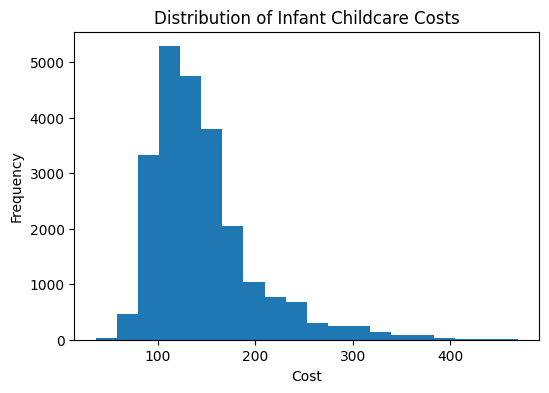

In [39]:
plt.figure(figsize=(6,4))
plt.hist(childcare["mc_infant"], bins=20)
plt.title("Distribution of Infant Childcare Costs")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()




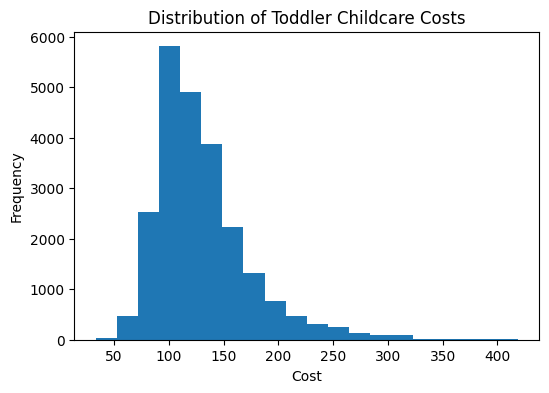

In [40]:
plt.figure(figsize=(6,4))
plt.hist(childcare["mc_toddler"], bins=20)
plt.title("Distribution of Toddler Childcare Costs")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()


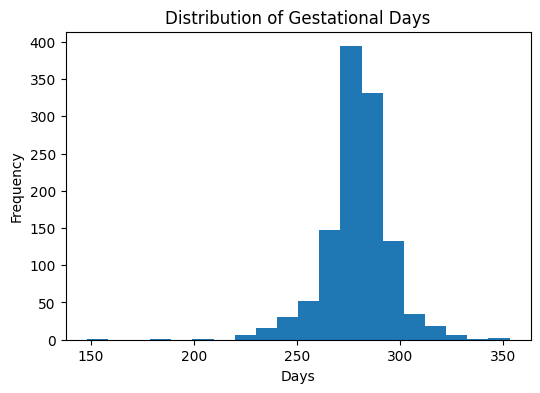

In [41]:
plt.figure(figsize=(6,4))
plt.hist(baby["gestational_days"], bins=20)
plt.title("Distribution of Gestational Days")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()




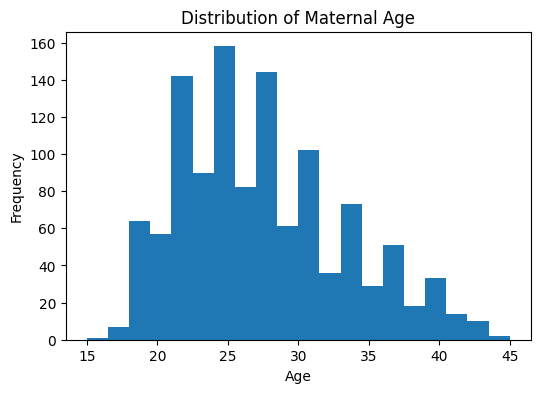

In [42]:
plt.figure(figsize=(6,4))
plt.hist(baby["maternal_age"], bins=20)
plt.title("Distribution of Maternal Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


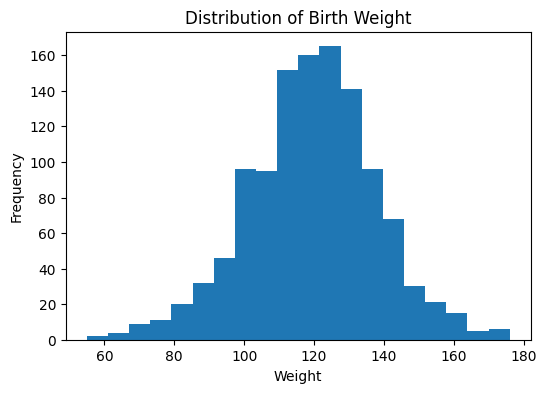

In [43]:
plt.figure(figsize=(6,4))
plt.hist(baby["birth_weight"], bins=20)
plt.title("Distribution of Birth Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()


## Exploratory Data Analysis

Two datasets were analysed: a childcare cost dataset and a baby/maternity dataset.
Basic cleaning was applied by removing missing values and standardising column names.
Exploratory analysis was conducted using summary statistics and visualisations to
understand data distributions and inform later modelling decisions.


In [44]:
baby_agg = baby.agg({
    "gestational_days": "mean",
    "maternal_age": "mean",
    "birth_weight": "mean",
    "maternal_pregnancy_weight": "mean"
}).to_frame().T


In [45]:
childcare["study_year"].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [46]:
years = pd.DataFrame({
    "study_year": childcare["study_year"].unique()
})


In [47]:
baby_by_year = years.merge(baby_agg, how="cross")


In [48]:
merged_df = childcare.merge(
    baby_by_year,
    on="study_year",
    how="left"
)


In [49]:
merged_df.shape
merged_df.head()


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,gestational_days,maternal_age,birth_weight,maternal_pregnancy_weight
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,104.95,104.95,85.92,83.45,83.45,81.40,279.101363,27.228279,119.462521,128.478705
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,105.11,105.11,87.59,87.39,87.39,85.68,279.101363,27.228279,119.462521,128.478705
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,105.28,105.28,89.26,91.33,91.33,89.96,279.101363,27.228279,119.462521,128.478705
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,105.45,105.45,90.93,95.28,95.28,94.25,279.101363,27.228279,119.462521,128.478705
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,105.61,105.61,92.60,99.22,99.22,98.53,279.101363,27.228279,119.462521,128.478705


In [50]:
"unnamed: 0" in merged_df.columns


False

In [51]:
target = "mc_infant"

features = [
    "study_year",
    "gestational_days",
    "maternal_age",
    "birth_weight",
    "maternal_pregnancy_weight",
    "unr_16",
    "unr_20to64",
    "total_pop"
]

X = merged_df[features]
y = merged_df[target]



In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mae


34.53793788664103